# Import Visualization Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load Results File

In [4]:
results_df = pd.read_csv("llm_fairness_results_score.csv", index_col=0)

results_df

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572


# ROUGE Score Comparison (Bar Graph)

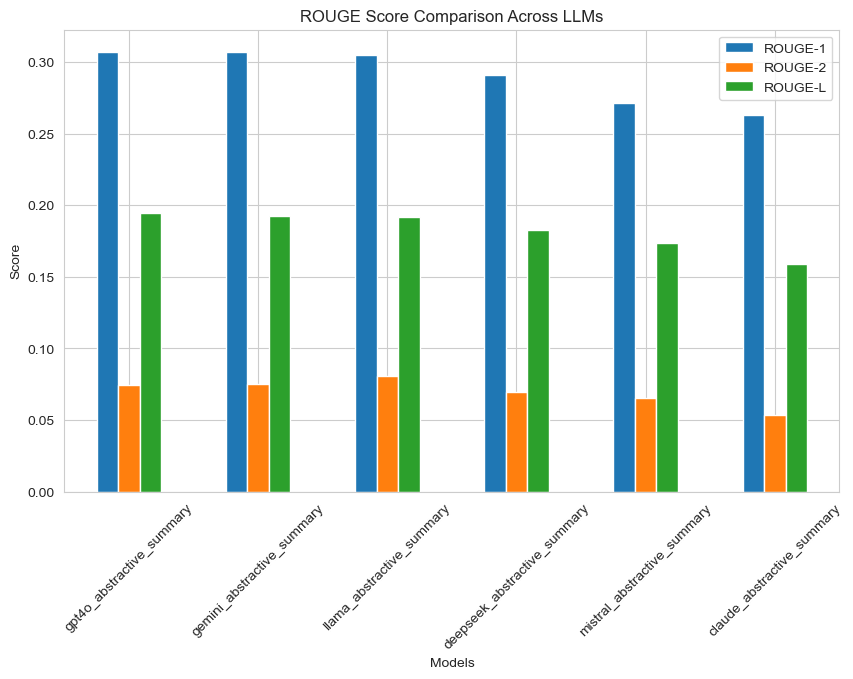

In [5]:
results_df[['ROUGE-1','ROUGE-2','ROUGE-L']].plot(kind='bar', figsize=(10,6))

plt.title("ROUGE Score Comparison Across LLMs")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# BLEU Score Graph

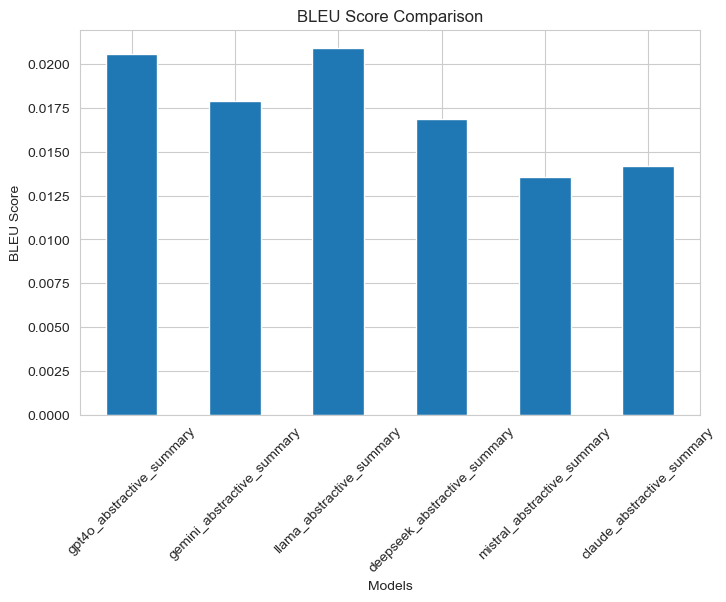

In [6]:
results_df['BLEU'].plot(kind='bar', figsize=(8,5))

plt.title("BLEU Score Comparison")
plt.ylabel("BLEU Score")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

# Sentiment Neutrality

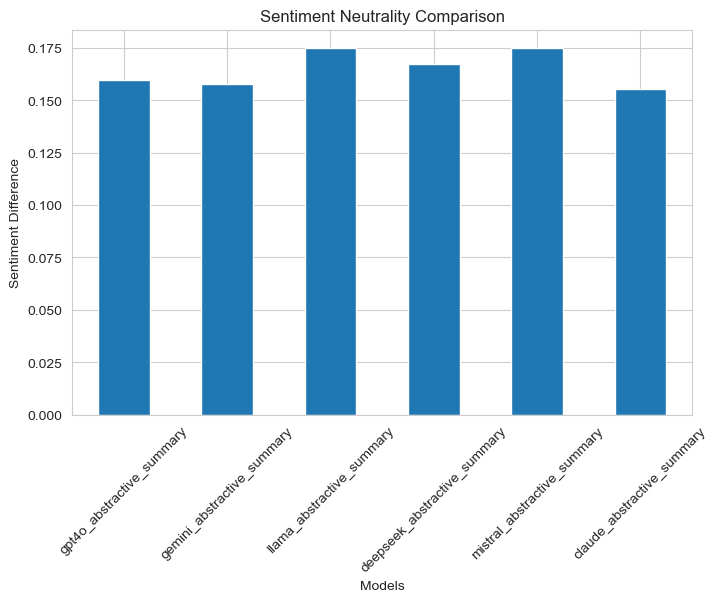

In [7]:
results_df['Sentiment Shift'].plot(kind='bar', figsize=(8,5))

plt.title("Sentiment Neutrality Comparison")
plt.ylabel("Sentiment Difference")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

# Coverage Fairness

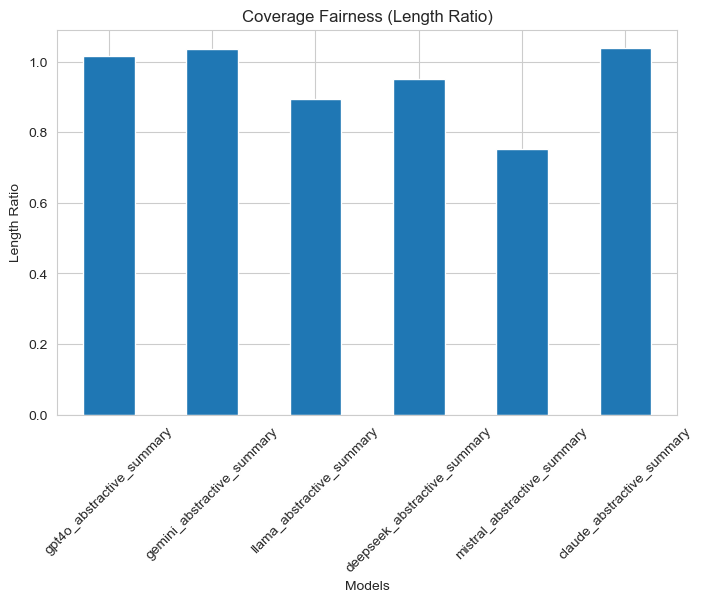

In [8]:
results_df['Avg Length Ratio'].plot(kind='bar', figsize=(8,5))

plt.title("Coverage Fairness (Length Ratio)")
plt.ylabel("Length Ratio")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

# Research Style Heatmap

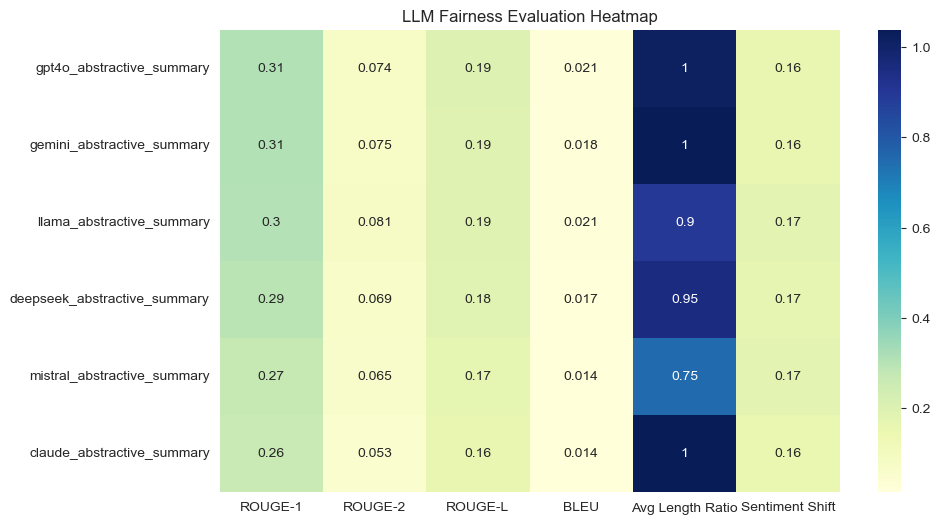

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(results_df, annot=True, cmap="YlGnBu")

plt.title("LLM Fairness Evaluation Heatmap")

plt.show()

# Model Ranking

In [11]:
results_df["Overall Score"] = (
    results_df["ROUGE-1"] +
    results_df["ROUGE-L"] +
    results_df["BLEU"]
) / 3

ranking = results_df.sort_values("Overall Score", ascending=False)

ranking

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift,Overall Score
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754,0.174044
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776,0.172634
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949,0.172464
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381,0.163447
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798,0.152883
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572,0.145484


# Visualize Model Ranking

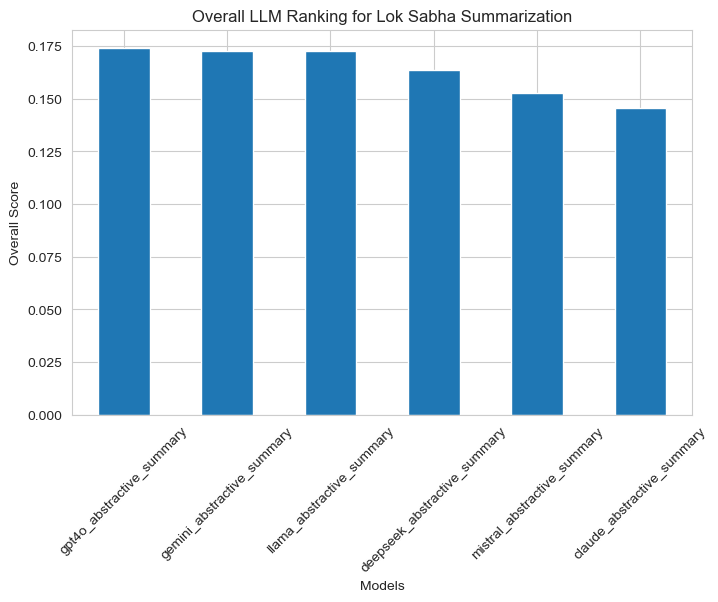

In [13]:
ranking["Overall Score"].plot(kind="bar", figsize=(8,5))

plt.title("Overall LLM Ranking for Lok Sabha Summarization")
plt.ylabel("Overall Score")
plt.xlabel("Models")

plt.xticks(rotation=45)

plt.show()

# Radar Chart (Best Research Comparison)

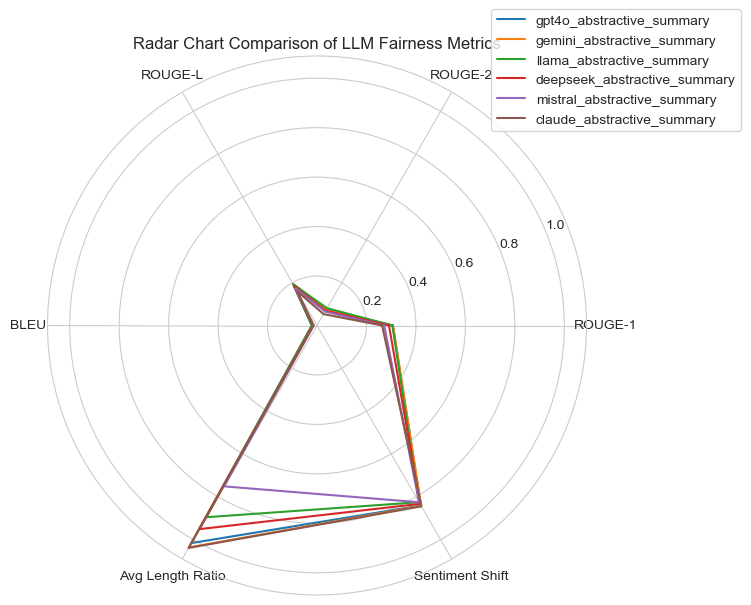

In [14]:
import numpy as np

metrics = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','Avg Length Ratio','Sentiment Shift']

data = results_df[metrics].copy()

# invert sentiment shift because lower is better
data["Sentiment Shift"] = 1 - data["Sentiment Shift"]

labels = list(data.columns)
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))

for model in data.index:
    values = data.loc[model].tolist()
    values += values[:1]
    plt.polar(angles, values, label=model)

plt.xticks(angles[:-1], labels)

plt.title("Radar Chart Comparison of LLM Fairness Metrics")

plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.show()

# Correlation Matrix (Metric Relationship)

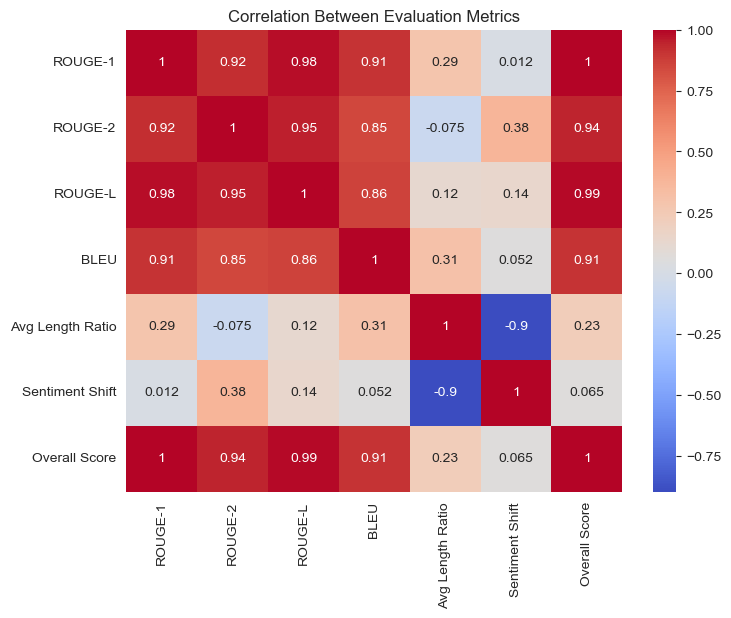

In [15]:
plt.figure(figsize=(8,6))

corr = results_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Evaluation Metrics")

plt.show()

# Summary Table for Report

In [17]:
summary = ranking[[
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "BLEU",
    "Avg Length Ratio",
    "Sentiment Shift",
    "Overall Score"
]]

summary

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift,Overall Score
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754,0.174044
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776,0.172634
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949,0.172464
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381,0.163447
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798,0.152883
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572,0.145484


# Define Political Entities

In [18]:
entities = ["modi", "rahul"]

# Function to Extract Sentiment Around Entities

In [19]:
from textblob import TextBlob

def entity_sentiment(text, entity):

    text = text.lower()

    if entity not in text:
        return None

    blob = TextBlob(text)

    return blob.sentiment.polarity

# Compute Sentiment for Reference vs LLM

In [22]:
df = pd.read_csv("final_merged_all_models_updated.csv")

df.head(1)

,post_id,subreddit,title,selftext,top_comments,full_content,word_count,score,num_comments,created_utc,url,bert_extractive_summary,claude_abstractive_summary,gemini_abstractive_summary,gpt4o_abstractive_summary,llama_abstractive_summary,mistral_abstractive_summary,deepseek_abstractive_summary
0,1d7qc1r,india,Opposition deserves some appreciation...,Finally after a long time we saw the election ...,Stronger opposition means there will be health...,Opposition deserves some appreciation... Final...,308,3724,468,04-06-2024 06:16,https://www.reddit.com/r/india/comments/1d7qc1...,For this opposition deserves a bit of praise f...,The opposition mounted a strategic and impress...,The user commends the opposition for transform...,The opposition in the 2024 Indian Lok Sabha el...,The opposition deserves credit for a well-plan...,The author commends the opposition's strategic...,The opposition's strategic campaign in the 202...


In [23]:
model_columns = [
    "gpt4o_abstractive_summary",
    "gemini_abstractive_summary",
    "llama_abstractive_summary",
    "deepseek_abstractive_summary",
    "mistral_abstractive_summary",
    "claude_abstractive_summary"
]

In [24]:
reference_column = "bert_extractive_summary"

entity_results = {}

for model in model_columns:

    modi_shift = []
    rahul_shift = []

    for i in range(len(df)):

        ref = str(df.loc[i, reference_column])
        pred = str(df.loc[i, model])

        ref_modi = entity_sentiment(ref, "modi")
        pred_modi = entity_sentiment(pred, "modi")

        ref_rahul = entity_sentiment(ref, "rahul")
        pred_rahul = entity_sentiment(pred, "rahul")

        if ref_modi is not None and pred_modi is not None:
            modi_shift.append(abs(ref_modi - pred_modi))

        if ref_rahul is not None and pred_rahul is not None:
            rahul_shift.append(abs(ref_rahul - pred_rahul))

    entity_results[model] = {
        "Modi Sentiment Shift": sum(modi_shift)/len(modi_shift) if modi_shift else 0,
        "Rahul Sentiment Shift": sum(rahul_shift)/len(rahul_shift) if rahul_shift else 0
    }

# Convert Results to Table

In [25]:
entity_df = pd.DataFrame(entity_results).T

entity_df

,Modi Sentiment Shift,Rahul Sentiment Shift
gpt4o_abstractive_summary,0.131765,0.183887
gemini_abstractive_summary,0.148183,0.211887
llama_abstractive_summary,0.144262,0.256759
deepseek_abstractive_summary,0.133451,0.199331
mistral_abstractive_summary,0.163760,0.191395
claude_abstractive_summary,0.126439,0.194647


# Plot Political Bias Graph

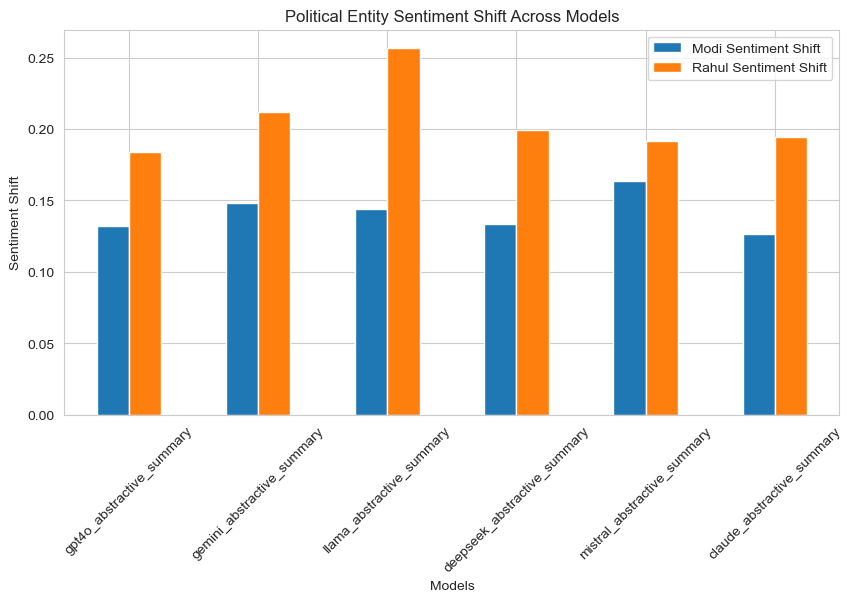

In [26]:
entity_df.plot(kind="bar", figsize=(10,5))

plt.title("Political Entity Sentiment Shift Across Models")
plt.ylabel("Sentiment Shift")
plt.xlabel("Models")

plt.xticks(rotation=45)

plt.show()

# LLM summarization quality by comparing generated summaries with an extractive BERT reference summary using ROUGE-L thresholds

In [27]:
from rouge_score import rouge_scorer
import pandas as pd

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

reference_column = "bert_extractive_summary"

matrix = []

for i in range(len(df)):

    ref = str(df.loc[i, reference_column])

    row = {"post": i}

    for model in model_columns:

        pred = str(df.loc[i, model])

        score = scorer.score(ref, pred)['rougeL'].fmeasure

        if score > 0.20:
            label = "Good"
        elif score > 0.15:
            label = "OK"
        else:
            label = "Poor"

        row[model] = label

    matrix.append(row)

matrix_df = pd.DataFrame(matrix)

matrix_df.head()

,post,gpt4o_abstractive_summary,gemini_abstractive_summary,llama_abstractive_summary,deepseek_abstractive_summary,mistral_abstractive_summary,claude_abstractive_summary
0,0,OK,Poor,Poor,Poor,Poor,Poor
1,1,OK,Good,Good,Good,Good,OK
2,2,Poor,Poor,Good,Poor,Poor,Poor
3,3,OK,OK,OK,OK,Poor,OK
4,4,Good,Good,Good,Good,Good,OK
